<a href="https://colab.research.google.com/github/AlThorStormblessed/CASSPNet/blob/main/Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import os
import glob
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Input, MultiHeadAttention, GlobalAveragePooling1D, LayerNormalization

os.chdir("drive/MyDrive/Cyber_paper") #to get into DAKOTA folder, comment out if already in there
current_dir = os.getcwd()
data_dir = current_dir + '/DATA'
print("Current Data Dir: ", data_dir)
all_sess = glob.glob("DATA/*")

Current Data Dir:  /content/drive/.shortcut-targets-by-id/1jGIW3h58xi_jlt4C_g__NYXv3EEhfefz/Cyber_paper/DATA


In [ ]:
n = 1
sessions = all_sess[:]
tl = sessions[n]
del sessions[n]
df = pd.read_csv(glob.glob(f"{tl}/merged_features_all.csv")[0])
df["LABEL"] = 1
df.head()

,X_acc_mean,X_acc_std,X_acc_median,X_acc_min,X_acc_max,X_acc_var,X_acc_kurtosis,X_acc_skew,Y_acc_mean,Y_acc_std,...,CURRENT_PRESSURE_median,CURRENT_SIZE_median,distance,directionOfEndtoEnfLine,ratio,duration,averageVelocity,MeanResultantLength,AverageDirectionEnsemble,LABEL
0,-1.310324,0.051823,-1.350466,-1.350466,-1.250112,0.002686,1.166667,0.484123,5.490721,0.023500,...,1.0,0.007874,348.919762,-1.386329,1.061229,145.0,2.267507,0.607557,3.0251,1
1,-1.110855,0.003531,-1.109521,-1.118862,-1.109521,0.000012,5.166667,-2.645751,5.515664,0.038564,...,1.0,0.007874,351.677409,-1.323749,0.966173,93.0,3.913872,0.607557,3.0251,1
2,-1.081498,0.000000,-1.081498,-1.081498,-1.081498,0.000000,0.000000,0.000000,5.505570,0.000000,...,1.0,0.007874,306.027946,-1.397296,0.900998,92.0,3.691895,0.607557,3.0251,1
3,-1.037669,0.000000,-1.037669,-1.037669,-1.037669,0.000000,0.000000,0.000000,5.556586,0.000000,...,1.0,0.007874,347.247750,-1.293683,0.956803,80.0,4.536561,0.607557,3.0251,1
4,-1.064733,0.000000,-1.064733,-1.064733,-1.064733,0.000000,0.000000,0.000000,5.512516,0.000000,...,1.0,0.007874,338.586769,-1.332265,0.840804,105.0,3.835180,0.607557,3.0251,1


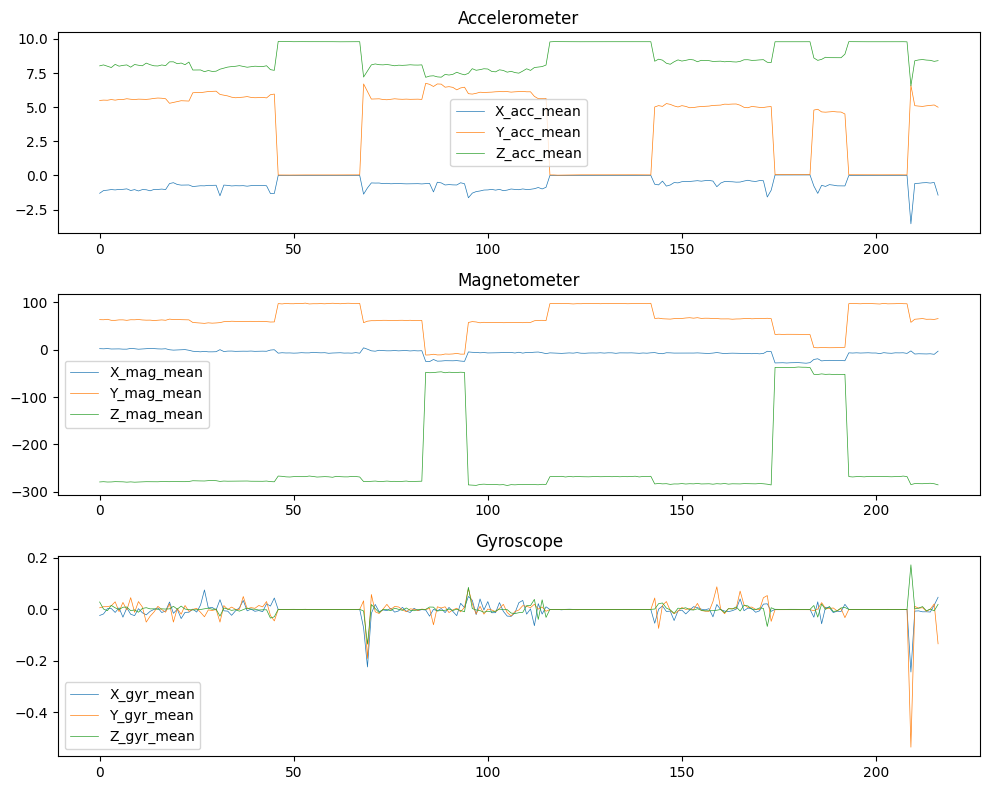

In [ ]:
import matplotlib.pyplot as plt

figure, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 8))

axes[0].plot(df[df.columns[0]], linewidth=0.5, zorder=1, label=df.columns[0])
axes[0].plot(df[df.columns[8]], linewidth=0.5, zorder=1, label=df.columns[8])
axes[0].plot(df[df.columns[16]], linewidth=0.5, zorder=1, label=df.columns[16])
axes[0].legend()
axes[0].set_title('Accelerometer')

axes[1].plot(df[df.columns[24]], linewidth=0.5, zorder=1, label=df.columns[24])
axes[1].plot(df[df.columns[32]], linewidth=0.5, zorder=1, label=df.columns[32])
axes[1].plot(df[df.columns[40]], linewidth=0.5, zorder=1, label=df.columns[40])
axes[1].legend()
axes[1].set_title('Magnetometer')

axes[2].plot(df[df.columns[48]], linewidth=0.5, zorder=1, label=df.columns[48])
axes[2].plot(df[df.columns[56]], linewidth=0.5, zorder=1, label=df.columns[56])
axes[2].plot(df[df.columns[64]], linewidth=0.5, zorder=1, label=df.columns[64])
axes[2].legend()
axes[2].set_title('Gyroscope')

plt.tight_layout()
plt.show()

In [ ]:
df.shape

(217, 127)

In [ ]:

df2 = pd.concat((pd.read_csv(glob.glob(f"{tl}/merged_features_all.csv")[0]) for tl in sessions))
df2["LABEL"] = 0
df2.head()

,X_acc_mean,X_acc_std,X_acc_median,X_acc_min,X_acc_max,X_acc_var,X_acc_kurtosis,X_acc_skew,Y_acc_mean,Y_acc_std,...,CURRENT_PRESSURE_median,CURRENT_SIZE_median,distance,directionOfEndtoEnfLine,ratio,duration,averageVelocity,MeanResultantLength,AverageDirectionEnsemble,LABEL
0,-0.112532,0.001131,-0.113168,-0.113407,-0.111012,1.280100e-06,1.418860,0.666515,0.049339,0.001247,...,1.0,0.007874,474.751514,2.875156,1.050318,417.0,1.083950,0.942169,-1.420466,0
1,-0.110522,0.002033,-0.112210,-0.112210,-0.107419,4.132803e-06,1.649341,0.598118,0.039671,0.001095,...,1.0,0.007874,531.700017,3.049169,0.828595,351.0,1.828172,0.942169,-1.420466,0
2,-0.114545,0.002035,-0.113407,-0.117958,-0.113407,4.141676e-06,2.333333,-1.277753,0.049279,0.000321,...,1.0,0.007874,626.766304,2.883457,0.869186,248.0,2.907645,0.942169,-1.420466,0
3,-0.115487,0.000179,-0.115563,-0.115563,-0.115084,3.220493e-08,4.520833,2.041206,0.051343,0.001227,...,1.0,0.007874,581.046049,2.840878,0.838510,301.0,2.302162,0.942169,-1.420466,0
4,-0.114650,0.002054,-0.113168,-0.117479,-0.113168,4.219834e-06,1.497891,-0.747596,0.050262,0.003198,...,1.0,0.007874,448.377073,2.959944,0.794971,322.0,1.751605,0.942169,-1.420466,0


In [ ]:

merged_df = pd.concat((df, df2))

columns = merged_df.columns

scaler = MinMaxScaler()
model = scaler.fit(merged_df)
scaled_data = pd.DataFrame(model.transform(merged_df), columns= columns)
print(scaled_data.shape)
scaled_data["LABEL"].value_counts()

(11545, 127)


,count
LABEL,
0.0,11328
1.0,217


In [ ]:
scaled_data.head()

,X_acc_mean,X_acc_std,X_acc_median,X_acc_min,X_acc_max,X_acc_var,X_acc_kurtosis,X_acc_skew,Y_acc_mean,Y_acc_std,...,CURRENT_PRESSURE_median,CURRENT_SIZE_median,distance,directionOfEndtoEnfLine,ratio,duration,averageVelocity,MeanResultantLength,AverageDirectionEnsemble,LABEL
0,0.425137,0.008826,0.422155,0.506990,0.415595,7.790455e-05,0.039636,0.577507,0.592683,0.015814,...,0.0,0.06477,0.187632,0.279348,0.037187,0.018001,0.024378,0.603745,0.981544,1.0
1,0.439955,0.000601,0.440054,0.521670,0.425918,3.615790e-07,0.175532,0.258621,0.594890,0.025951,...,0.0,0.06477,0.189117,0.289309,0.033856,0.011546,0.042078,0.603745,0.981544,1.0
2,0.442136,0.000000,0.442136,0.524038,0.427976,0.000000e+00,0.000000,0.528183,0.593997,0.000000,...,0.0,0.06477,0.164524,0.277603,0.031572,0.011421,0.039691,0.603745,0.981544,1.0
3,0.445392,0.000000,0.445392,0.526816,0.431194,0.000000e+00,0.000000,0.528183,0.598511,0.000000,...,0.0,0.06477,0.186731,0.294094,0.033528,0.009932,0.048772,0.603745,0.981544,1.0
4,0.443381,0.000000,0.443381,0.525101,0.429207,0.000000e+00,0.000000,0.528183,0.594611,0.000000,...,0.0,0.06477,0.182065,0.287953,0.029463,0.013035,0.041232,0.603745,0.981544,1.0


In [ ]:

# print(scaled_data)

train, validate, test = \
              np.split(scaled_data.sample(frac=1, random_state=42),
                       [int(.88*len(scaled_data)), int(.9*len(scaled_data))])

X_train_, y_train_ = train.drop("LABEL", axis=1), train["LABEL"]
X_test, y_test = test.drop("LABEL", axis=1), test["LABEL"]
X_val, y_val = validate.drop("LABEL", axis=1), validate["LABEL"]

# print(X_train.shape, y_train.shape)
# print(X_test.shape, y_test.shape)
# print(X_val.shape, y_val.shape)

/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [ ]:
from imblearn.over_sampling import ADASYN
sm = ADASYN(sampling_strategy = 0.7, n_neighbors = 6)
# print(len(X_train))
X_train, y_train = sm.fit_resample(X_train_, y_train_)
print(X_train.shape, y_train.shape)

(16931, 126) (16931,)


In [ ]:
from imblearn.over_sampling import SVMSMOTE
sm = SVMSMOTE(sampling_strategy = .7, k_neighbors = 10)
# print(len(X_train))
X_train, y_train = sm.fit_resample(X_train_, y_train_)
print(X_train.shape, y_train.shape)

In [ ]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(sampling_strategy = 0.7, k_neighbors = 5)
# print(len(X_train))
X_train, y_train = sm.fit_resample(X_train_, y_train_)
print(X_train.shape, y_train.shape)

(16942, 126) (16942,)


In [ ]:
X_train = np.resize(X_train, (X_train.shape[0], 126, 1))
X_test = np.resize(X_test, (X_test.shape[0], 126, 1))
print(X_train.shape)

(16942, 126, 1)


In [ ]:
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, max_len, d_model):
        super(PositionalEncoding, self).__init__()
        self.positional_encoding = self.get_positional_encoding(max_len, d_model)

    def get_positional_encoding(self, max_len, d_model):
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

        pos_encoding = angle_rads[np.newaxis, ...]
        return tf.cast(pos_encoding, dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.positional_encoding[:, :tf.shape(inputs)[1], :]


class ContAuth_trans:
    def __init__(self, hidden_units, dropout_rate, input_shape, num_classes, learning_rate, batch_size, early_stopping_threshold, alpha):
        self.hidden_units = hidden_units
        self.dropout_rate = dropout_rate
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.early_stopping_threshold = early_stopping_threshold
        self.alpha = alpha
        self.model = self.create_model()

    def create_model(self):
        inputs = Input(shape=self.input_shape)

        position_encoding = PositionalEncoding(self.input_shape[0], self.hidden_units)(inputs)

        x = Dense(self.hidden_units, activation='relu')(position_encoding)
        x = Dropout(self.dropout_rate)(x)

        attention = MultiHeadAttention(num_heads=4, key_dim=self.hidden_units)(x, x)
        attention = Dropout(self.dropout_rate)(attention)
        attention = LayerNormalization()(attention)

        attention = MultiHeadAttention(num_heads=8, key_dim=int(self.hidden_units/2))(attention, attention)
        attention = Dropout(self.dropout_rate)(attention)
        attention = LayerNormalization()(attention)

        x = GlobalAveragePooling1D()(attention)

        x = Dense(128, activation='relu')(x)
        x = Dropout(self.dropout_rate)(x)
        outputs = Dense(self.num_classes, activation='softmax')(x)

        model = Model(inputs=inputs, outputs=outputs)
        return model

    def compile_model(self):
        optimizer = Adam(learning_rate=self.learning_rate)
        self.model.compile(optimizer=optimizer,
                           loss='sparse_categorical_crossentropy',
                           metrics=['accuracy'])

    def train_model(self, X_train, y_train, X_val, y_val, epochs):
        early_stopping = EarlyStopping(monitor='val_loss',
                                       patience=20,
                                       min_delta=self.early_stopping_threshold,
                                       restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=2, min_lr=0.00001, mode='auto', verbose=1)
        checkpointer = ModelCheckpoint("saved_model/model_t2.keras", verbose=1, save_best_only=True)

        history = self.model.fit(X_train, y_train,
                                 validation_data=(X_val, y_val),
                                 epochs=epochs,
                                 batch_size=self.batch_size,
                                 callbacks=[early_stopping, reduce_lr, checkpointer])
        return history

    def extract_features(self, X):
        feature_extractor = Model(inputs=self.model.input, outputs=self.model.get_layer(index=-4).output)
        features = feature_extractor.predict(X)
        return features

    def train_sgd_classifier(self, X_train_features, y_train, X_val_features, y_val):
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_features)
        X_val_scaled = scaler.transform(X_val_features)

        sgd = SGDClassifier(loss='hinge', penalty='elasticnet', alpha=self.alpha, l1_ratio=0.5, max_iter=1000, tol=1e-3)
        sgd.fit(X_train_scaled, y_train)

        y_val_pred = sgd.predict(X_val_scaled)
        accuracy = accuracy_score(y_val, y_val_pred)
        return sgd, accuracy

    def data_incremental_training(self, X_new, y_new, X_test, y_test, epochs):
        history = self.train_model(X_new, y_new, X_test, y_test, epochs)

        X_train_features = self.extract_features(X_new)
        X_test_features = self.extract_features(X_test)

        sgd, accuracy = self.train_sgd_classifier(X_train_features, y_new, X_test_features, y_test)

        return history, accuracy

hidden_units = 256
dropout_rate = 0.5
input_shape = (126, 1)
num_classes = 2
learning_rate = 0.001
batch_size = 32
early_stopping_threshold = 0.00001
alpha = 0.01

try:
    del model
except:
    pass

model = ContAuth_trans(hidden_units, dropout_rate, input_shape, num_classes, learning_rate, batch_size, early_stopping_threshold, alpha)
model.compile_model()

# Print model summary
print(model.model.summary())


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 126, 1)         │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ positional_encoding       │ (None, 126, 256)       │              0 │ input_layer[0][0]      │
│ (PositionalEncoding)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 126, 256)       │         65,792 │ positional_encoding[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 126, 256)       │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention      │ (None, 126, 256)       │      1,051,904 │ dropout[0][0],         │
│ (MultiHeadAttention)      │                        │                │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 126, 256)       │              0 │ multi_head_attention[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization       │ (None, 126, 256)       │            512 │ dropout_2[0][0]        │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_1    │ (None, 126, 256)       │      1,051,904 │ layer_normalization[0… │
│ (MultiHeadAttention)      │                        │                │ layer_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_4 (Dropout)       │ (None, 126, 256)       │              0 │ multi_head_attention_… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_1     │ (None, 126, 256)       │            512 │ dropout_4[0][0]        │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling1d  │ (None, 256)            │              0 │ layer_normalization_1… │
│ (GlobalAveragePooling1D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 128)            │         32,896 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_5 (Dropout)       │ (None, 128)            │              0 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 2)              │            258 │ dropout_5[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 2,203,778 (8.41 MB)

 Trainable params: 2,203,778 (8.41 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
class ContAuth:
    def __init__(self, hidden_units, dropout_rate, input_shape, num_classes, learning_rate, batch_size, early_stopping_threshold, alpha):
        self.hidden_units = hidden_units
        self.dropout_rate = dropout_rate
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.early_stopping_threshold = early_stopping_threshold
        self.alpha = alpha
        self.model = self.create_model()

    def create_model(self):
        inputs = Input(shape=self.input_shape)
        x = LSTM(self.hidden_units, return_sequences=False)(inputs)
        x = Dropout(self.dropout_rate)(x)
        x = Dense(int(self.hidden_units/2), activation='relu')(x)
        x = Dropout(self.dropout_rate)(x)
        outputs = Dense(self.num_classes, activation='sigmoid')(x)

        model = Model(inputs=inputs, outputs=outputs)
        return model

    def compile_model(self):
        optimizer = Adam(learning_rate=self.learning_rate)
        self.model.compile(optimizer=optimizer,
                           loss='sparse_categorical_crossentropy',
                           metrics=['accuracy'])

    def train_model(self, X_train, y_train, X_val, y_val, epochs):
        if(epochs > 20): pat = 20
        else: pat = 2

        early_stopping = EarlyStopping(monitor='val_loss',
                                       patience=pat,
                                       min_delta=self.early_stopping_threshold,
                                       restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=2, min_lr=0.00001, mode='auto', verbose=1)
        checkpointer = ModelCheckpoint("saved_model/model_t2.keras", verbose=1, save_best_only=True)

        history = self.model.fit(X_train, y_train,
                                 validation_data=(X_val, y_val),
                                 epochs=epochs,
                                 batch_size=self.batch_size,
                                 callbacks=[early_stopping, reduce_lr, checkpointer])

        return history

    def extract_features(self, X):
        feature_extractor = Model(inputs=self.model.input, outputs=self.model.layers[-1].output)
        features = feature_extractor.predict(X)
        return features

    def train_sgd_classifier(self, X_train_features, y_train, X_val_features, y_val):
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_features)
        X_val_scaled = scaler.transform(X_val_features)

        sgd = SGDClassifier(loss='hinge', penalty='elasticnet', alpha=self.alpha, l1_ratio=0.5, max_iter=1000, tol=1e-3)
        sgd.fit(X_train_scaled, y_train)

        y_val_pred = sgd.predict(X_val_scaled)
        accuracy = accuracy_score(y_val, y_val_pred)
        return sgd, accuracy

    def data_incremental_training(self, X_new, y_new, X_test, y_test, epochs):
        X_train_features = self.extract_features(X_new)
        X_test_features = self.extract_features(X_test)

        sgd, accuracy = self.train_sgd_classifier(X_train_features, y_new, X_test_features, y_test)

        y_new = y_new.values.reshape(-1, 1)
        y_test = y_test.values.reshape(-1, 1)

        history = self.train_model(X_new, y_new, X_test, y_test, epochs)
        return history, accuracy

hidden_units = 256
dropout_rate = 0.7
input_shape = (126, 1)
num_classes = 2
learning_rate = 0.001
batch_size = 64
early_stopping_threshold = 0.00001
alpha = 0.01

# Initialize and compile model
try: del model
except: pass

model = ContAuth(hidden_units, dropout_rate, input_shape, num_classes, learning_rate, batch_size, early_stopping_threshold, alpha)
model.compile_model()

# Print model summary
print(model.model.summary())


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 126, 1)]          0         
                                                                 
 lstm (LSTM)                 (None, 256)               264192    
                                                                 
 dropout_6 (Dropout)         (None, 256)               0         
                                                                 
 dense_9 (Dense)             (None, 128)               32896     
                                                                 
 dropout_7 (Dropout)         (None, 128)               0         
                                                                 
 dense_10 (Dense)            (None, 2)                 258       
                                                                 
Total params: 297346 (1.13 MB)
Trainable params: 297346 (1.13

In [ ]:
import mlrose_hiive as mlrose
import numpy as np
from keras.layers import LSTM, Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score


class ContAuth:
    def __init__(self, hidden_units, dropout_rate, input_shape, num_classes, learning_rate, batch_size, early_stopping_threshold, alpha):
        self.hidden_units = hidden_units
        self.dropout_rate = dropout_rate
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.early_stopping_threshold = early_stopping_threshold
        self.alpha = alpha
        self.model = self.create_model()

    def create_model(self):
        inputs = Input(shape=self.input_shape)
        x = LSTM(self.hidden_units, return_sequences=False)(inputs)
        x = Dropout(self.dropout_rate)(x)
        x = Dense(self.hidden_units, activation='relu')(x)
        x = Dropout(self.dropout_rate)(x)
        outputs = Dense(self.num_classes, activation='sigmoid')(x)

        model = Model(inputs=inputs, outputs=outputs)
        return model

    def compile_model(self):
        optimizer = Adam(learning_rate=self.learning_rate)
        self.model.compile(optimizer=optimizer,
                           loss='sparse_categorical_crossentropy',
                           metrics=['accuracy'])

    def train_model(self, X_train, y_train, X_val, y_val, epochs):
        if epochs > 20:
            pat = 20
        else:
            pat = 2

        early_stopping = EarlyStopping(monitor='val_loss',
                                       patience=pat,
                                       min_delta=self.early_stopping_threshold,
                                       restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=2, min_lr=0.00001, mode='auto', verbose=1)
        checkpointer = ModelCheckpoint("saved_model/model_t2.keras", verbose=1, save_best_only=True)

        history = self.model.fit(X_train, y_train,
                                 validation_data=(X_val, y_val),
                                 epochs=epochs,
                                 batch_size=self.batch_size,
                                 callbacks=[early_stopping, reduce_lr, checkpointer])

        return history

    def extract_features(self, X):
        feature_extractor = Model(inputs=self.model.input, outputs=self.model.layers[-1].output)
        features = feature_extractor.predict(X)
        return features

    def train_sgd_classifier(self, X_train_features, y_train, X_val_features, y_val):
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_features)
        X_val_scaled = scaler.transform(X_val_features)

        sgd = SGDClassifier(loss='hinge', penalty='elasticnet', alpha=self.alpha, l1_ratio=0.5, max_iter=1000, tol=1e-3)
        sgd.fit(X_train_scaled, y_train)

        y_val_pred = sgd.predict(X_val_scaled)
        accuracy = accuracy_score(y_val, y_val_pred)
        return sgd, accuracy

    def data_incremental_training(self, X_new, y_new, X_test, y_test, epochs):
        X_train_features = self.extract_features(X_new)
        X_test_features = self.extract_features(X_test)

        sgd, accuracy = self.train_sgd_classifier(X_train_features, y_new, X_test_features, y_test)

        y_new = y_new.values.reshape(-1, 1)
        y_test = y_test.values.reshape(-1, 1)

        history = self.train_model(X_new, y_new, X_test, y_test, epochs)
        return history, accuracy


def fitness_function(params):
    # Map params to the real hyperparameter ranges
    hidden_units = int(params[0] * (512 - 64) + 64)  # Map 0.0-1.0 to 64-512
    dropout_rate = params[1] * (0.7 - 0.2) + 0.2  # Map 0.0-1.0 to 0.2-0.7
    learning_rate = params[2] * (0.01 - 0.0001) + 0.0001  # Map 0.0-1.0 to 0.0001-0.01
    batch_size = int(params[3] * (128 - 16) + 16)  # Map 0.0-1.0 to 16-128

    # Initialize ContAuth with the mapped hyperparameters
    cont_auth_model = ContAuth(hidden_units=hidden_units,
                               dropout_rate=dropout_rate,
                               input_shape=(X_train.shape[1], X_train.shape[2]),
                               num_classes=2,
                               learning_rate=learning_rate,
                               batch_size=batch_size,
                               early_stopping_threshold=0.001,
                               alpha=0.01)

    cont_auth_model.compile_model()

    # Train and evaluate the model on validation data
    history = cont_auth_model.train_model(X_train, y_train, X_val, y_val, epochs=5)

    # Get validation accuracy
    val_accuracy = max(history.history['val_accuracy'])

    return -val_accuracy


problem = mlrose.ContinuousOpt(length=4,  # 4 hyperparameters to optimize
                               fitness_fn=mlrose.CustomFitness(fitness_function),
                               maximize=True,
                               min_val=0.0,  # Minimum value for all parameters
                               max_val=1.0,  # Maximum value for all parameters
                               step=0.25)


# Optimize hyperparameters using a genetic algorithm
best_params, best_fitness = mlrose.genetic_alg(problem, max_iters=5, random_state=42)

# Extract best hyperparameters
best_hidden_units = int(best_params[0])
best_dropout_rate = best_params[1]
best_learning_rate = best_params[2]
best_batch_size = int(best_params[3])

print(f"Best Hidden Units: {best_hidden_units}")
print(f"Best Dropout Rate: {best_dropout_rate}")
print(f"Best Learning Rate: {best_learning_rate}")
print(f"Best Batch Size: {best_batch_size}")


# Train final model with the best hyperparameters
final_model = ContAuth(hidden_units=best_hidden_units,
                       dropout_rate=best_dropout_rate,
                       input_shape=(X_train.shape[1], X_train.shape[2]),
                       num_classes=2,
                       learning_rate=best_learning_rate,
                       batch_size=best_batch_size,
                       early_stopping_threshold=0.001,
                       alpha=0.01)

final_model.compile_model()

# Train the model
final_history = final_model.train_model(X_train, y_train, X_test, y_test, epochs=50)

# Evaluate on test data
final_loss, final_accuracy = final_model.model.evaluate(X_test, y_test)
print(f"Final Test Accuracy: {final_accuracy}")


Epoch 1/5
202/204 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5547 - loss: 0.7263
Epoch 1: val_loss improved from inf to 0.52142, saving model to saved_model/model_t2.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.5549 - loss: 0.7260 - val_accuracy: 0.9827 - val_loss: 0.5214 - learning_rate: 0.0073
Epoch 2/5
201/204 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5962 - loss: 0.6752
Epoch 2: val_loss did not improve from 0.52142
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5961 - loss: 0.6753 - val_accuracy: 0.9827 - val_loss: 0.5330 - learning_rate: 0.0073
Epoch 3/5
201/204 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5868 - loss: 0.6787
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0036733699962496758.

Epoch 3: val_loss did not improve from 0.52142
204/204 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5868 - loss: 0.6787 - val_accuracy: 0.9827 - val_loss: 0.5402 - learning_rate: 0.0073
Epoch 1/5
148/150 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step -

In [ ]:
import pennylane as qml
from pennylane import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

class ContAuth:
    def __init__(self, hidden_units, dropout_rate, input_shape, num_classes, num_qubits, learning_rate, batch_size, early_stopping_threshold, alpha):
        self.hidden_units = hidden_units
        self.dropout_rate = dropout_rate
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.early_stopping_threshold = early_stopping_threshold
        self.alpha = alpha
        self.num_qubits = num_qubits
        self.model = self.create_model()
        self.dev = qml.device("default.qubit", wires=self.num_qubits)

    def quantum_circuit(self, features, weights):
        @qml.qnode(self.dev)
        def circuit(features, weights):
            # Feature encoding
            for i in range(self.num_qubits):
                qml.RX(features[i % len(features)], wires=i)
                qml.RY(features[i % len(features)], wires=i)

            # Variational circuit
            for i in range(len(weights)):
                qml.Rot(*weights[i][:3], wires=0)
                qml.CNOT(wires=[0, 1])
                qml.Rot(*weights[i][3:6], wires=1)
                qml.CNOT(wires=[1, 2])
                qml.Rot(*weights[i][6:9], wires=2)
                qml.CNOT(wires=[2, 3])
                qml.Rot(*weights[i][9:12], wires=3)

            # Measurement
            return [qml.expval(qml.PauliZ(i)) for i in range(self.num_qubits)]

        return circuit(features, weights)

    def hybrid_model(self, X):
        quantum_weights = np.random.uniform(size=(3, 12))  # Random weights for 3 layers
        quantum_results = np.array([self.quantum_circuit(x[:self.num_qubits], quantum_weights) for x in X])
        X_new = np.column_stack((X, quantum_results))  # Combine classical and quantum features
        return X_new

    def create_model(self):
        model = Sequential()
        model.add(Dense(256, activation="relu", input_shape=(self.input_shape[0] + self.num_qubits, )))
        model.add(Dropout(self.dropout_rate))
        model.add(Dense(128, activation="relu"))
        model.add(Dropout(self.dropout_rate))
        model.add(Dense(64, activation="relu"))
        model.add(Dropout(self.dropout_rate))
        model.add(Dense(1, activation="sigmoid"))  # Binary classification
        return model

    def compile_model(self):
        optimizer = Adam(learning_rate = self.learning_rate)
        self.model.compile(optimizer=optimizer,
                           loss='binary_crossentropy',
                           metrics=['accuracy'])

    def train_model(self, X_train, y_train, X_val, y_val, epochs):
        if(epochs > 20): pat = 200
        else: pat = 2

        early_stopping = EarlyStopping(monitor='val_loss',
                                       patience=pat,
                                       min_delta=self.early_stopping_threshold,
                                       restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=2, min_lr=0.00001, mode='auto', verbose=1)
        checkpointer = ModelCheckpoint("saved_model/model_t2.keras", verbose=1, save_best_only=True)

        X_train_q = self.hybrid_model(X_train)
        X_val_q = self.hybrid_model(X_val)

        history = self.model.fit(X_train_q, y_train,
                                 validation_data=(X_val_q, y_val),
                                 epochs=epochs,
                                 batch_size=self.batch_size,
                                 callbacks=[early_stopping, reduce_lr, checkpointer])

        return history

    def extract_features(self, X):
        feature_extractor = Model(inputs=self.model.input, outputs=self.model.layers[-1].output)
        features = feature_extractor.predict(X)
        return features

    def train_sgd_classifier(self, X_train_features, y_train, X_val_features, y_val):
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_features)
        X_val_scaled = scaler.transform(X_val_features)

        sgd = SGDClassifier(loss='hinge', penalty='elasticnet', alpha=self.alpha, l1_ratio=0.5, max_iter=1000, tol=1e-3)
        sgd.fit(X_train_scaled, y_train)

        y_val_pred = sgd.predict(X_val_scaled)
        accuracy = accuracy_score(y_val, y_val_pred)
        return sgd, accuracy

    def data_incremental_training(self, X_new, y_new, X_test, y_test, epochs):
        X_new_q = self.hybrid_model(X_new)
        X_test_q = self.hybrid_model(X_test)

        X_train_features = self.extract_features(X_new_q)
        X_test_features = self.extract_features(X_test_q)

        print(X_train_features.shape)

        sgd, accuracy = self.train_sgd_classifier(X_train_features, y_new, X_test_features, y_test)

        y_new = y_new.values.reshape(-1, 1)
        y_test = y_test.values.reshape(-1, 1)

        history = self.train_model(X_new, y_new, X_test, y_test, epochs)
        return history, accuracy

hidden_units = 256
dropout_rate = 0.3
input_shape = (126, 1)
num_classes = 2
learning_rate = 0.001
batch_size = 32
early_stopping_threshold = 0.00001
alpha = 0.01
num_qubits = 4

# Initialize and compile model
try: del model
except: pass

model = ContAuth(hidden_units, dropout_rate, input_shape, num_classes, num_qubits, learning_rate, batch_size, early_stopping_threshold, alpha)
model.compile_model()

# Print model summary
print(model.model.summary())


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 256)               33536     
                                                                 
 dropout_3 (Dropout)         (None, 256)               0         
                                                                 
 dense_5 (Dense)             (None, 128)               32896     
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 dense_6 (Dense)             (None, 64)                8256      
                                                                 
 dropout_5 (Dropout)         (None, 64)                0         
                                                                 
 dense_7 (Dense)             (None, 1)                

In [ ]:
import pennylane as qml
from pennylane import numpy as np
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Concatenate, Reshape
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

class QNNLSTMHybrid:
    def __init__(self, hidden_units, dropout_rate, input_shape, num_classes, num_qubits, learning_rate, batch_size, early_stopping_threshold, alpha):
        self.hidden_units = hidden_units
        self.dropout_rate = dropout_rate
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.early_stopping_threshold = early_stopping_threshold
        self.alpha = alpha
        self.num_qubits = num_qubits
        self.dev = qml.device("default.qubit", wires=self.num_qubits)
        self.model = self.create_model()

    def quantum_circuit(self, features, weights):
        @qml.qnode(self.dev)
        def circuit(features, weights):
            # Feature encoding
            for i in range(self.num_qubits):
                qml.RX(features[i % len(features)], wires=i)
                qml.RY(features[i % len(features)], wires=i)

            # Variational circuit
            for i in range(len(weights)):
                qml.Rot(*weights[i][:3], wires=0)
                qml.CNOT(wires=[0, 1])
                qml.Rot(*weights[i][3:6], wires=1)
                qml.CNOT(wires=[1, 2])
                qml.Rot(*weights[i][6:9], wires=2)
                qml.CNOT(wires=[2, 3])
                qml.Rot(*weights[i][9:12], wires=3)

            # Measurement
            return [qml.expval(qml.PauliZ(i)) for i in range(self.num_qubits)]

        return circuit(features, weights)

    def hybrid_model(self, X):
        quantum_weights = np.random.uniform(size=(3, 12))  # Random weights for 3 layers
        quantum_results = np.array([self.quantum_circuit(x[:self.num_qubits], quantum_weights) for x in X])
        X_new = np.column_stack((X, quantum_results))  # Combine classical and quantum features
        return X_new

    def create_model(self):

        # Quantum feature extraction
        quantum_input_layer = Input(shape=(self.input_shape[0] + self.num_qubits,))
        reshaped_input = Reshape((-1, self.input_shape[0] + self.num_qubits))(quantum_input_layer)

        lstm_layer = LSTM(self.hidden_units, activation="tanh", return_sequences=False)(reshaped_input)
        lstm_output = Dropout(self.dropout_rate)(lstm_layer)

        # Fully connected layers
        fc1 = Dense(128, activation="relu")(lstm_output)
        fc2 = Dropout(self.dropout_rate)(fc1)
        fc3 = Dense(64, activation="relu")(fc2)
        fc4 = Dropout(self.dropout_rate)(fc3)
        output_layer = Dense(1, activation="sigmoid")(fc4)

        model = Model(inputs=quantum_input_layer, outputs=output_layer)
        return model

    def compile_model(self):
        optimizer = Adam(learning_rate = self.learning_rate)
        self.model.compile(optimizer=optimizer,
                           loss='binary_crossentropy',
                           metrics=['accuracy'])

    def train_model(self, X_train, y_train, X_val, y_val, epochs):
        if(epochs > 20): pat = 40
        else: pat = 2

        early_stopping = EarlyStopping(monitor='val_loss',
                                       patience=pat,
                                       min_delta=self.early_stopping_threshold,
                                       restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=5, min_lr=0.00001, mode='auto', verbose=1)
        checkpointer = ModelCheckpoint("saved_model/model_t2.keras", verbose=1, save_best_only=True)

        X_train_q = self.hybrid_model(X_train)
        X_val_q = self.hybrid_model(X_val)

        history = self.model.fit(X_train_q, y_train,
                                 validation_data=(X_val_q, y_val),
                                 epochs=epochs,
                                 batch_size=self.batch_size,
                                 callbacks=[early_stopping, reduce_lr, checkpointer])

        return history

    def extract_features(self, X):
        feature_extractor = Model(inputs=self.model.input, outputs=self.model.layers[-1].output)
        features = feature_extractor.predict(X)
        return features

    def train_sgd_classifier(self, X_train_features, y_train, X_val_features, y_val):
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_features)
        X_val_scaled = scaler.transform(X_val_features)

        sgd = SGDClassifier(loss='hinge', penalty='elasticnet', alpha=self.alpha, l1_ratio=0.5, max_iter=1000, tol=1e-3)
        sgd.fit(X_train_scaled, y_train)

        y_val_pred = sgd.predict(X_val_scaled)
        accuracy = accuracy_score(y_val, y_val_pred)
        return sgd, accuracy

    def data_incremental_training(self, X_new, y_new, X_test, y_test, epochs):
        X_new_q = self.hybrid_model(X_new)
        X_test_q = self.hybrid_model(X_test)

        X_train_features = self.extract_features(X_new_q)
        X_test_features = self.extract_features(X_test_q)

        print(X_train_features.shape)

        sgd, accuracy = self.train_sgd_classifier(X_train_features, y_new, X_test_features, y_test)

        y_new = y_new.values.reshape(-1, 1)
        y_test = y_test.values.reshape(-1, 1)

        history = self.train_model(X_new, y_new, X_test, y_test, epochs)
        return history, accuracy

# Define parameters
hidden_units = 256
dropout_rate = 0.3
input_shape = (126, 1)
num_classes = 2
learning_rate = 0.001
batch_size = 32
early_stopping_threshold = 0.00001
alpha = 0.01
num_qubits = 4

# Initialize and compile the hybrid model
try: del model
except: pass

model = QNNLSTMHybrid(hidden_units, dropout_rate, input_shape, num_classes, num_qubits, learning_rate, batch_size, early_stopping_threshold, alpha)
model.compile_model()

# Print model summary
print(model.model.summary())

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 130)]             0         
                                                                 
 reshape_1 (Reshape)         (None, 1, 130)            0         
                                                                 
 lstm_1 (LSTM)               (None, 256)               396288    
                                                                 
 dropout_3 (Dropout)         (None, 256)               0         
                                                                 
 dense_3 (Dense)             (None, 128)               32896     
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 dense_4 (Dense)             (None, 64)                8256

In [ ]:
#Initial training
# After running one of above five

history = model.train_model(X_train, y_train, X_test, y_test, 300)

Epoch 1/300
524/530 [============================>.] - ETA: 0s - loss: 0.1661 - accuracy: 0.9366
Epoch 1: val_loss improved from inf to 0.13544, saving model to saved_model/model_t2.keras
530/530 [==============================] - 6s 7ms/step - loss: 0.1659 - accuracy: 0.9368 - val_loss: 0.1354 - val_accuracy: 0.9437 - lr: 0.0010
Epoch 2/300
524/530 [============================>.] - ETA: 0s - loss: 0.0848 - accuracy: 0.9735
Epoch 2: val_loss improved from 0.13544 to 0.11680, saving model to saved_model/model_t2.keras
530/530 [==============================] - 4s 8ms/step - loss: 0.0844 - accuracy: 0.9736 - val_loss: 0.1168 - val_accuracy: 0.9619 - lr: 0.0010
Epoch 3/300
528/530 [============================>.] - ETA: 0s - loss: 0.0638 - accuracy: 0.9819
Epoch 3: val_loss improved from 0.11680 to 0.08383, saving model to saved_model/model_t2.keras
530/530 [==============================] - 3s 5ms/step - loss: 0.0639 - accuracy: 0.9819 - val_loss: 0.0838 - val_accuracy: 0.9714 - lr: 0.0

In [ ]:
#Data incremental learning

#New data is X_val, y_val

X_val = np.resize(X_val, (X_val.shape[0], 126, 1))
X_val_train, X_val_test, y_val_train, y_val_test = train_test_split(X_val, y_val, test_size=0.2, random_state=42)

# history = model.train_model(X_val_train, y_val_train, X_val_test, y_val_test, 100)
history1, accuracy = model.data_incremental_training(X_val_train, y_val_train, X_val_test, y_val_test, 10)
print("Accuracy: ", accuracy)

2/2 [==============================] - 0s 7ms/step
(184, 1)
Epoch 1/10
6/6 [==============================] - ETA: 0s - loss: 4.7254e-07 - accuracy: 1.0000
Epoch 1: val_loss improved from inf to 0.00005, saving model to saved_model/model_t2.keras
6/6 [==============================] - 0s 46ms/step - loss: 4.7254e-07 - accuracy: 1.0000 - val_loss: 5.1690e-05 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 2/10
1/6 [====>.........................] - ETA: 0s - loss: 1.3793e-11 - accuracy: 1.0000
Epoch 2: val_loss did not improve from 0.00005
6/6 [==============================] - 0s 12ms/step - loss: 2.0792e-05 - accuracy: 1.0000 - val_loss: 5.1783e-05 - val_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 3/10
1/6 [====>.........................] - ETA: 0s - loss: 1.3222e-07 - accuracy: 1.0000
Epoch 3: val_loss did not improve from 0.00005
6/6 [==============================] - 0s 14ms/step - loss: 8.1070e-08 - accuracy: 1.0000 - val_loss: 5.1871e-05 - val_accuracy: 1.0000 - lr: 1.0000e-05
Accuracy

In [ ]:
model_loaded = model.model

dev = qml.device("default.qubit", wires = num_qubits)
@qml.qnode(dev)
def quantum_circuit(features, weights):
    for i in range(num_qubits):
        qml.RX(features[i % len(features)], wires=i)
        qml.RY(features[i % len(features)], wires=i)

    for i in range(len(weights)):
        qml.Rot(*weights[i][:3], wires=0)
        qml.CNOT(wires=[0, 1])
        qml.Rot(*weights[i][3:6], wires=1)
        qml.CNOT(wires=[1, 2])
        qml.Rot(*weights[i][6:9], wires=2)
        qml.CNOT(wires=[2, 3])
        qml.Rot(*weights[i][9:12], wires=3)

    return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]

def hybrid_model(X):
    quantum_weights = np.random.uniform(size=(3, 12))
    quantum_results = np.array([quantum_circuit(x[:num_qubits], quantum_weights) for x in X])
    X_new = np.column_stack((X, quantum_results))
    return X_new

# while best_accuracy < 0.9982:
X_test_q = hybrid_model(X_test)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve
predictions = model_loaded.predict(X_test_q)

thresholds = np.arange(0.001, 1.001, 0.001)

best_threshold = 0.0
best_accuracy = 0.0

for threshold in thresholds:
    labels = [1 if pred > threshold else 0 for pred in predictions[:, 0]]

    accuracy = accuracy_score(y_test, labels)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_threshold = threshold

final_labels = [1 if pred > best_threshold else 0 for pred in predictions[:, 0]]
conf_matrix = confusion_matrix(y_test, final_labels)

TN, FP, FN, TP = conf_matrix.ravel()
FAR = FP / (FP + TN)
FRR = FN / (FN + TP)

print(f"Optimal Threshold: {best_threshold:.3f}")
print(f"Best Accuracy: {best_accuracy:.4f}")
print(f"False Acceptance Rate (FAR): {FAR:.4f}")
print(f"False Rejection Rate (FRR): {FRR:.4f}")

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, predictions[:, 0])
frr = 1 - tpr
eer_threshold = thresholds[np.nanargmin(np.abs(frr - fpr))]
eer = fpr[np.nanargmin(np.abs(frr - fpr))]

print(f"EER Threshold: {eer_threshold:.3f}")
print(f"Equal Error Rate (EER): {eer:.4f}")

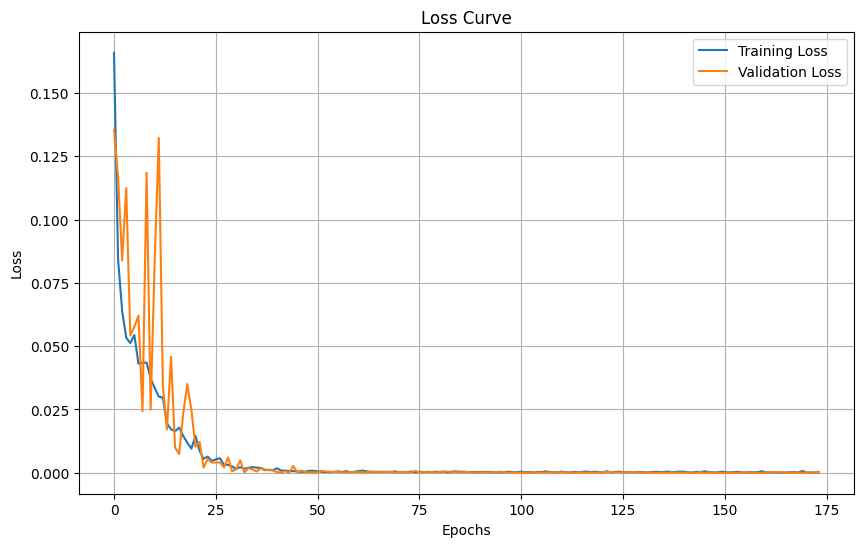

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig("Loss_LSTM.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Acc')
plt.plot(history.history['val_accuracy'], label='Validation Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig("Acc_LSTM.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
!pip install pennylane pennylane-qiskit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.0/930.0 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.9/249.9 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB